In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv("ai_tools_comparison.csv")


In [25]:
print("\n Full Dataset:\n")
print(df)


 Full Dataset:

           Tool  Response_Time  Accuracy  Task_Completion  Engagement  \
0       ChatGPT            3.2        95               94           5   
1       ChatGPT            3.1        96               95           5   
2       ChatGPT            3.4        94               93           5   
3       ChatGPT            3.0        97               96           5   
4       ChatGPT            3.3        95               94           5   
5       ChatGPT            3.5        93               92           4   
6       ChatGPT            3.2        96               95           5   
7       ChatGPT            3.1        95               94           5   
8       ChatGPT            3.3        94               93           5   
9       ChatGPT            3.2        96               95           5   
10      ChatGPT            3.6        92               91           4   
11      ChatGPT            3.0        97               96           5   
12      ChatGPT            3.4    

In [26]:
# Basic Statistics

In [27]:
summary = df.groupby("Tool").mean()

In [28]:
print("\n Average Performance:\n")
print(summary)


 Average Performance:

             Response_Time  Accuracy  Task_Completion  Engagement  Usability
Tool                                                                        
AI_Platform          6.940     84.60            84.20        4.00        4.0
ChatGPT              3.250     95.00            94.00        4.85        5.0
ITS                  5.625     87.75            87.25        3.00        3.0


In [29]:
# Ranking Logic

In [30]:
# Normalizing response time (lower is better)
summary["Normalized_Time"] = summary["Response_Time"].max() - summary["Response_Time"]

In [31]:
# Compute overall score
summary["Overall_Score"] = (
    summary["Accuracy"] * 0.3 +
    summary["Task_Completion"] * 0.25 +
    summary["Engagement"] * 0.2 +
    summary["Usability"] * 0.15 +
    summary["Normalized_Time"] * 0.1
)

In [32]:
print("\n Overall Scores:\n")
print(summary["Overall_Score"])


 Overall Scores:

Tool
AI_Platform    47.830
ChatGPT        54.089
ITS            49.319
Name: Overall_Score, dtype: float64


In [33]:
best_tool = summary["Overall_Score"].idxmax()


In [34]:
print(f"\n Best Performing Tool: {best_tool}")


 Best Performing Tool: ChatGPT


In [35]:
# Detailed Insights

In [36]:
print("\n Insights:")

for tool in summary.index:
    print(f"\n{tool}:")
    print(f"  Avg Response Time: {summary.loc[tool, 'Response_Time']:.2f} sec")
    print(f"  Accuracy: {summary.loc[tool, 'Accuracy']:.2f}%")
    print(f"  Completion: {summary.loc[tool, 'Task_Completion']:.2f}%")



 Insights:

AI_Platform:
  Avg Response Time: 6.94 sec
  Accuracy: 84.60%
  Completion: 84.20%

ChatGPT:
  Avg Response Time: 3.25 sec
  Accuracy: 95.00%
  Completion: 94.00%

ITS:
  Avg Response Time: 5.62 sec
  Accuracy: 87.75%
  Completion: 87.25%


In [37]:
# Visualization

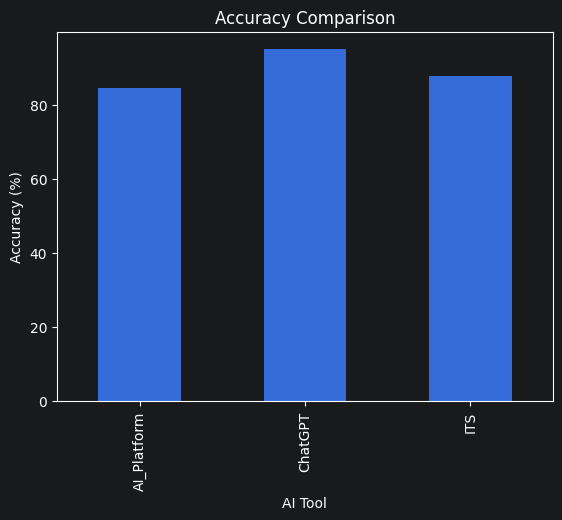

In [38]:
# Accuracy Comparison

plt.figure()
summary["Accuracy"].plot(kind='bar')
plt.title("Accuracy Comparison")
plt.xlabel("AI Tool")
plt.ylabel("Accuracy (%)")
plt.show()


In [39]:
# Response Time Comparison

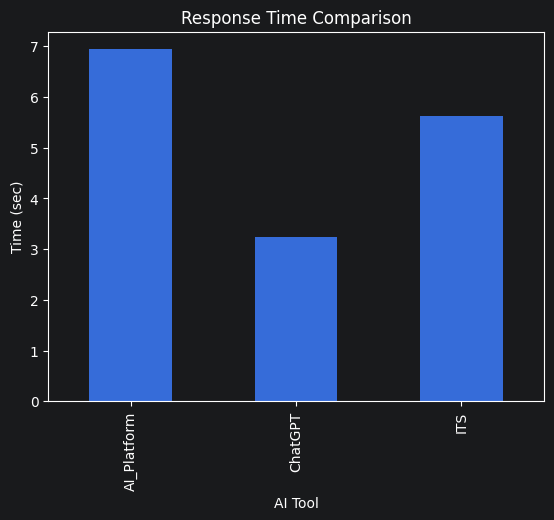

In [40]:
plt.figure()
summary["Response_Time"].plot(kind='bar')
plt.title("Response Time Comparison")
plt.xlabel("AI Tool")
plt.ylabel("Time (sec)")
plt.show()

In [41]:
# Overall Scores

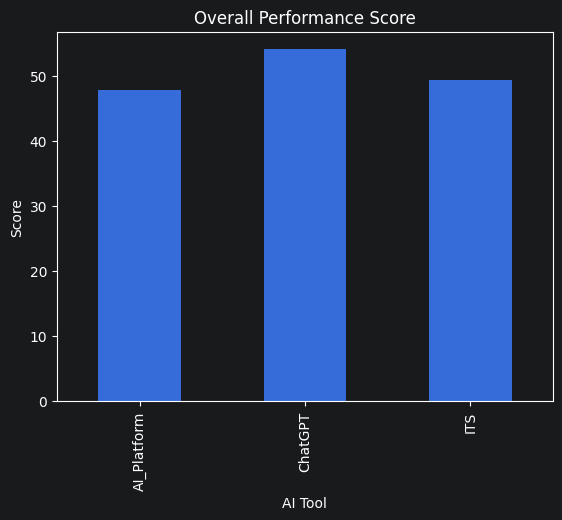

In [42]:
plt.figure()
summary["Overall_Score"].plot(kind='bar')
plt.title("Overall Performance Score")
plt.xlabel("AI Tool")
plt.ylabel("Score")
plt.show()